# Load dataset

In [13]:

!pip install kagglehub -q

import kagglehub
import os


path = kagglehub.dataset_download(
    "nodoubttome/skin-cancer9-classesisic"
)

print("Kaggle dataset path:")
print(path)

print("\nContents:")
print(os.listdir(path))

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Kaggle dataset path:
/kaggle/input/skin-cancer9-classesisic

Contents:
['Skin cancer ISIC The International Skin Imaging Collaboration']


# Set Train/Test paths and verify classes

In [14]:


import os

DATASET_ROOT = os.path.join(
    path,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)

TRAIN_DIR = os.path.join(
    DATASET_ROOT,
    "Train"
)

TEST_DIR = os.path.join(
    DATASET_ROOT,
    "Test"
)

SELECTED_CLASSES = [
    "melanoma",
    "pigmented benign keratosis",
    "basal cell carcinoma",
    "nevus"
]

print("Dataset root:")
print(DATASET_ROOT)

print("\nTrain exists:", os.path.exists(TRAIN_DIR))
print("Test exists :", os.path.exists(TEST_DIR))

print("\nTrain class folders:")
print(os.listdir(TRAIN_DIR))

print("\nSelected class check:")

for class_name in SELECTED_CLASSES:

    train_class_path = os.path.join(
        TRAIN_DIR,
        class_name
    )

    test_class_path = os.path.join(
        TEST_DIR,
        class_name
    )

    print(
        f"{class_name:30s} | "
        f"Train: {os.path.exists(train_class_path)} | "
        f"Test: {os.path.exists(test_class_path)}"
    )

Dataset root:
/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration

Train exists: True
Test exists : True

Train class folders:
['pigmented benign keratosis', 'melanoma', 'vascular lesion', 'actinic keratosis', 'squamous cell carcinoma', 'basal cell carcinoma', 'seborrheic keratosis', 'dermatofibroma', 'nevus']

Selected class check:
melanoma                       | Train: True | Test: True
pigmented benign keratosis     | Train: True | Test: True
basal cell carcinoma           | Train: True | Test: True
nevus                          | Train: True | Test: True


# Count images in the 4 selected classes

In [15]:


import os

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)

def count_images(folder):

    count = 0

    for file_name in os.listdir(folder):

        if file_name.lower().endswith(
            VALID_EXTENSIONS
        ):
            count += 1

    return count


print("IMAGE COUNTS\n")

for class_name in SELECTED_CLASSES:

    train_class_path = os.path.join(
        TRAIN_DIR,
        class_name
    )

    test_class_path = os.path.join(
        TEST_DIR,
        class_name
    )

    train_count = count_images(
        train_class_path
    )

    test_count = count_images(
        test_class_path
    )

    print(
        f"{class_name:30s} | "
        f"Train: {train_count:3d} | "
        f"Test: {test_count:2d} | "
        f"Total: {train_count + test_count:3d}"
    )

IMAGE COUNTS

melanoma                       | Train: 438 | Test: 16 | Total: 454
pigmented benign keratosis     | Train: 462 | Test: 16 | Total: 478
basal cell carcinoma           | Train: 376 | Test: 16 | Total: 392
nevus                          | Train: 357 | Test: 16 | Total: 373


# Create training and testing dataframes

In [18]:


import pandas as pd
import os

CLASS_TO_IDX = {
    "melanoma": 0,
    "pigmented benign keratosis": 1,
    "basal cell carcinoma": 2,
    "nevus": 3
}


def collect_images(folder):

    records = []

    for class_name in SELECTED_CLASSES:

        class_folder = os.path.join(
            folder,
            class_name
        )

        for file_name in os.listdir(
            class_folder
        ):

            if file_name.lower().endswith(
                VALID_EXTENSIONS
            ):

                records.append({
                    "path": os.path.join(
                        class_folder,
                        file_name
                    ),
                    "class_name": class_name,
                    "label": CLASS_TO_IDX[
                        class_name
                    ]
                })

    return pd.DataFrame(records)


# Create dataframes
train_df = collect_images(
    TRAIN_DIR
)

test_df = collect_images(
    TEST_DIR
)


print("Training dataframe size:", len(train_df))
print("Testing dataframe size :", len(test_df))


print("\nTraining class distribution:")
print(
    train_df["class_name"].value_counts()
)


print("\nTesting class distribution:")
print(
    test_df["class_name"].value_counts()
)


print("\nLabel mapping:")
for class_name, label in CLASS_TO_IDX.items():
    print(
        f"{label} -> {class_name}"
    )

Training dataframe size: 1633
Testing dataframe size : 64

Training class distribution:
class_name
pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
Name: count, dtype: int64

Testing class distribution:
class_name
melanoma                      16
pigmented benign keratosis    16
basal cell carcinoma          16
nevus                         16
Name: count, dtype: int64

Label mapping:
0 -> melanoma
1 -> pigmented benign keratosis
2 -> basal cell carcinoma
3 -> nevus


# Train/validation split

In [19]:


from sklearn.model_selection import train_test_split

train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("Training images   :", len(train_split_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))


print("\nTraining distribution:")
print(
    train_split_df["class_name"].value_counts()
)


print("\nValidation distribution:")
print(
    val_df["class_name"].value_counts()
)


print("\nTesting distribution:")
print(
    test_df["class_name"].value_counts()
)

Training images   : 1306
Validation images : 327
Testing images    : 64

Training distribution:
class_name
pigmented benign keratosis    369
melanoma                      350
basal cell carcinoma          301
nevus                         286
Name: count, dtype: int64

Validation distribution:
class_name
pigmented benign keratosis    93
melanoma                      88
basal cell carcinoma          75
nevus                         71
Name: count, dtype: int64

Testing distribution:
class_name
melanoma                      16
pigmented benign keratosis    16
basal cell carcinoma          16
nevus                         16
Name: count, dtype: int64


# IMAGE PREPROCESSING & AUGMENTATION

In [20]:


from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("Training transform ready!")
print("Validation/Test transform ready!")

Training transform ready!
Validation/Test transform ready!


#  CUSTOM DATASET + DATALOADERS

In [21]:


from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch


class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = SkinCancerDataset(
    train_split_df,
    train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    eval_transform
)

test_dataset = SkinCancerDataset(
    test_df,
    eval_transform
)




BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


print("DataLoaders created successfully!")

print("\nTraining images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Testing images    :", len(test_dataset))

print("\nTraining batches   :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Testing batches    :", len(test_loader))

DataLoaders created successfully!

Training images   : 1306
Validation images : 327
Testing images    : 64

Training batches   : 41
Validation batches : 11
Testing batches    : 2


# GPU + CLASS WEIGHTS

In [22]:


import numpy as np
import torch


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



NUM_CLASSES = 4



class_counts = np.bincount(
    train_split_df["label"].values,
    minlength=NUM_CLASSES
)

print("\nClass counts:", class_counts)




class_weights_np = (
    len(train_split_df)
    /
    (NUM_CLASSES * class_counts)
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=device
)

print("Class weights:", class_weights)



if np.any(class_counts == 0):
    raise ValueError(
        "One or more classes have 0 training images."
    )

print("\n✓ GPU and class weights are ready.")

Device: cuda
GPU: Tesla T4

Class counts: [350 369 301 286]
Class weights: tensor([0.9329, 0.8848, 1.0847, 1.1416], device='cuda:0')

✓ GPU and class weights are ready.


# Define all 8 transfer-learning models

In [23]:


import torch.nn as nn
from torchvision import models


def create_model(model_name):

    # --------------------------------------------------------
    # AlexNet
    # --------------------------------------------------------
    if model_name == "AlexNet":

        model = models.alexnet(
            weights=models.AlexNet_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # VGG16
    # --------------------------------------------------------
    elif model_name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # VGG19
    # --------------------------------------------------------
    elif model_name == "VGG19":

        model = models.vgg19(
            weights=models.VGG19_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # ResNet18
    # --------------------------------------------------------
    elif model_name == "ResNet18":

        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # ResNet50
    # --------------------------------------------------------
    elif model_name == "ResNet50":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # ResNet101
    # --------------------------------------------------------
    elif model_name == "ResNet101":

        model = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # DenseNet121
    # --------------------------------------------------------
    elif model_name == "DenseNet121":

        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # EfficientNet-B0
    # --------------------------------------------------------
    elif model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )


    else:

        raise ValueError(
            f"Unknown model name: {model_name}"
        )


    return model.to(device)


# ============================================================
# MODEL ORDER REQUIRED FOR TABLE 1
# ============================================================

MODEL_ORDER = [
    "AlexNet",
    "VGG16",
    "VGG19",
    "ResNet18",
    "ResNet50",
    "ResNet101",
    "DenseNet121",
    "EfficientNet-B0"
]


print("All 8 models are defined successfully!")

print("\nModels:")
for model_name in MODEL_ORDER:
    print("-", model_name)

All 8 models are defined successfully!

Models:
- AlexNet
- VGG16
- VGG19
- ResNet18
- ResNet50
- ResNet101
- DenseNet121
- EfficientNet-B0


# Common training function

In [24]:



import copy
import torch

EPOCHS = 10
LEARNING_RATE = 0.0001


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    accumulation_steps=1
):

    # --------------------------------------------------------
    # Loss and optimizer
    # --------------------------------------------------------

    criterion = torch.nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # --------------------------------------------------------
    # Mixed precision
    # Helps training speed and GPU memory
    # --------------------------------------------------------

    use_amp = (
        device.type == "cuda"
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )


    # --------------------------------------------------------
    # Variables for best model
    # --------------------------------------------------------

    best_val_accuracy = -1.0
    best_epoch = 0
    best_state = None


    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }


    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(EPOCHS):


        # ====================================================
        # TRAINING
        # ====================================================

        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        optimizer.zero_grad(
            set_to_none=True
        )


        for batch_index, (
            images,
            labels
        ) in enumerate(train_loader):


            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            # Forward pass
            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )


            # Store normal loss
            train_loss_sum += (
                loss.item()
                * labels.size(0)
            )


            # Gradient accumulation
            loss_to_backward = (
                loss
                / accumulation_steps
            )


            scaler.scale(
                loss_to_backward
            ).backward()


            # Update weights
            should_update = (

                (
                    batch_index + 1
                ) % accumulation_steps == 0

                or

                (
                    batch_index + 1
                ) == len(train_loader)
            )


            if should_update:

                scaler.step(
                    optimizer
                )

                scaler.update()

                optimizer.zero_grad(
                    set_to_none=True
                )


            # Predictions
            predictions = torch.argmax(
                outputs,
                dim=1
            )


            train_correct += (
                predictions == labels
            ).sum().item()


            train_total += labels.size(0)


        # Training results
        train_loss = (
            train_loss_sum
            / train_total
        )

        train_accuracy = (
            train_correct
            / train_total
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for images, labels in val_loader:


                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )


                # Use normal float32 for validation
                outputs = model(
                    images
                )


                loss = criterion(
                    outputs,
                    labels
                )


                val_loss_sum += (
                    loss.item()
                    * labels.size(0)
                )


                predictions = torch.argmax(
                    outputs,
                    dim=1
                )


                val_correct += (
                    predictions == labels
                ).sum().item()


                val_total += labels.size(0)


        val_loss = (
            val_loss_sum
            / val_total
        )

        val_accuracy = (
            val_correct
            / val_total
        )


        # ====================================================
        # SAVE HISTORY
        # ====================================================

        history["epoch"].append(
            epoch + 1
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )


        # ====================================================
        # KEEP BEST VALIDATION MODEL
        # ====================================================

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1


            # Save best weights on CPU
            # so large models do not waste GPU memory
            best_state = {

                key:
                value.detach()
                .cpu()
                .clone()

                for key, value
                in model.state_dict().items()
            }


        # ====================================================
        # PRINT EACH EPOCH
        # ====================================================

        print(

            f"{model_name:16s} | "

            f"Epoch "
            f"{epoch + 1:02d}/{EPOCHS} | "

            f"Train Acc: "
            f"{train_accuracy * 100:6.2f}% | "

            f"Val Acc: "
            f"{val_accuracy * 100:6.2f}% | "

            f"Train Loss: "
            f"{train_loss:.4f} | "

            f"Val Loss: "
            f"{val_loss:.4f}"
        )


    # ========================================================
    # RESTORE BEST MODEL
    # ========================================================

    model.load_state_dict(
        best_state
    )

    model = model.to(
        device
    )


    print("\n" + "=" * 60)

    print(
        f"{model_name} training complete"
    )

    print(
        f"Best Epoch              : {best_epoch}"
    )

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy * 100:.2f}%"
    )

    print("=" * 60)


    return (
        model,
        history,
        best_val_accuracy,
        best_epoch
    )


print("✓ Common 10-epoch training function created.")
print("✓ Epochs:", EPOCHS)
print("✓ Learning rate:", LEARNING_RATE)

✓ Common 10-epoch training function created.
✓ Epochs: 10
✓ Learning rate: 0.0001


# Model-specific DataLoaders

In [26]:


from torch.utils.data import DataLoader


def create_model_loaders(model_name):

    # --------------------------------------------------------
    # Heavy VGG models
    # --------------------------------------------------------
    if model_name in [
        "VGG16",
        "VGG19"
    ]:

        batch_size = 8
        accumulation_steps = 4


    # --------------------------------------------------------
    # AlexNet
    # --------------------------------------------------------
    elif model_name == "AlexNet":

        batch_size = 16
        accumulation_steps = 2


    # --------------------------------------------------------
    # ResNets, DenseNet, EfficientNet
    # --------------------------------------------------------
    else:

        batch_size = 32
        accumulation_steps = 1


    # ========================================================
    # TRAIN LOADER
    # ========================================================

    train_loader_current = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )


    # ========================================================
    # VALIDATION LOADER
    # ========================================================

    val_loader_current = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )


    # TEST LOADER
    # ========================================================

    test_loader_current = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )


    return (
        train_loader_current,
        val_loader_current,
        test_loader_current,
        batch_size,
        accumulation_steps
    )


# VERIFY SETTINGS FOR ALL MODELS

print("Model DataLoader settings:\n")

for model_name in MODEL_ORDER:

    if model_name in ["VGG16", "VGG19"]:
        batch_size = 8
        accumulation = 4

    elif model_name == "AlexNet":
        batch_size = 16
        accumulation = 2

    else:
        batch_size = 32
        accumulation = 1

    print(
        f"{model_name:16s} | "
        f"Batch Size: {batch_size:2d} | "
        f"Gradient Accumulation: {accumulation} | "
        f"Effective Batch: {batch_size * accumulation}"
    )

Model DataLoader settings:

AlexNet          | Batch Size: 16 | Gradient Accumulation: 2 | Effective Batch: 32
VGG16            | Batch Size:  8 | Gradient Accumulation: 4 | Effective Batch: 32
VGG19            | Batch Size:  8 | Gradient Accumulation: 4 | Effective Batch: 32
ResNet18         | Batch Size: 32 | Gradient Accumulation: 1 | Effective Batch: 32
ResNet50         | Batch Size: 32 | Gradient Accumulation: 1 | Effective Batch: 32
ResNet101        | Batch Size: 32 | Gradient Accumulation: 1 | Effective Batch: 32
DenseNet121      | Batch Size: 32 | Gradient Accumulation: 1 | Effective Batch: 32
EfficientNet-B0  | Batch Size: 32 | Gradient Accumulation: 1 | Effective Batch: 32


# TEST EVALUATION FUNCTION

In [27]:




import numpy as np
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_model(
    model,
    test_loader
):

    model.eval()

    all_true_labels = []
    all_predictions = []
    all_probabilities = []


    # ========================================================
    # MAKE PREDICTIONS
    # ========================================================

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            # Forward pass
            outputs = model(
                images
            )


            # ------------------------------------------------
            # Convert logits to float32 before Softmax
            # This prevents the AUC error we had earlier
            # ------------------------------------------------

            probabilities = F.softmax(
                outputs.float(),
                dim=1
            )


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            all_true_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )


    # ========================================================
    # CONVERT TO NUMPY
    # ========================================================

    y_true = np.array(
        all_true_labels
    )

    y_pred = np.array(
        all_predictions
    )

    y_prob = np.array(
        all_probabilities,
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Ensure each probability row sums exactly to 1
    # --------------------------------------------------------

    y_prob = (
        y_prob
        /
        y_prob.sum(
            axis=1,
            keepdims=True
        )
    )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )


    metrics = {

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1-Score (%)":
            f1 * 100,

        "AUC (%)":
            auc * 100
    }


    return (
        metrics,
        y_true,
        y_pred,
        y_prob
    )


print("✓ Test evaluation function created.")
print("✓ Metrics: Accuracy, Precision, Recall, F1-Score, AUC")
print("✓ Multiclass averaging: Macro")
print("✓ AUC method: One-vs-Rest (OvR)")

✓ Test evaluation function created.
✓ Metrics: Accuracy, Precision, Recall, F1-Score, AUC
✓ Multiclass averaging: Macro
✓ AUC method: One-vs-Rest (OvR)


# output folders


In [28]:


import os

OUTPUT_DIR = "/content/drive/MyDrive/SkinCancer_Task01_Results"

CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR,
    "checkpoints"
)

HISTORY_DIR = os.path.join(
    OUTPUT_DIR,
    "training_histories"
)

PREDICTION_DIR = os.path.join(
    OUTPUT_DIR,
    "predictions"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    HISTORY_DIR,
    exist_ok=True
)

os.makedirs(
    PREDICTION_DIR,
    exist_ok=True
)


print("✓ Output folder created")
print("✓ Checkpoint folder created")
print("✓ History folder created")
print("✓ Prediction folder created")

print("\nResults will be saved here:")
print(OUTPUT_DIR)

✓ Output folder created
✓ Checkpoint folder created
✓ History folder created
✓ Prediction folder created

Results will be saved here:
/content/drive/MyDrive/SkinCancer_Task01_Results


# Train all 8 models + build Table 1

In [29]:


import gc
import os
import numpy as np
import pandas as pd
import torch


# ============================================================
# STORAGE FOR RESULTS
# ============================================================

table1_results = []
training_summary = []


# ============================================================
# START ALL MODELS
# ============================================================

for model_index, model_name in enumerate(
    MODEL_ORDER,
    start=1
):

    print("\n\n")
    print("=" * 90)

    print(
        f"MODEL {model_index}/{len(MODEL_ORDER)}"
    )

    print(
        f"TRAINING {model_name} — {EPOCHS} EPOCHS"
    )

    print("=" * 90)


    # ========================================================
    # CLEAR GPU MEMORY
    # ========================================================

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # CREATE PRETRAINED MODEL
    # ========================================================

    current_model = create_model(
        model_name
    )


    # ========================================================
    # CREATE MODEL-SPECIFIC DATALOADERS
    # ========================================================

    (
        current_train_loader,
        current_val_loader,
        current_test_loader,
        batch_size,
        accumulation_steps
    ) = create_model_loaders(
        model_name
    )


    print(
        "\nPhysical Batch Size       :",
        batch_size
    )

    print(
        "Gradient Accumulation     :",
        accumulation_steps
    )

    print(
        "Effective Batch Size      :",
        batch_size * accumulation_steps
    )

    print(
        "Training Images           :",
        len(train_dataset)
    )

    print(
        "Validation Images         :",
        len(val_dataset)
    )

    print(
        "Testing Images            :",
        len(test_dataset)
    )

    print()


    # ========================================================
    # TRAIN MODEL
    # ========================================================

    (
        current_model,
        current_history,
        best_val_accuracy,
        best_epoch
    ) = train_model(

        model=current_model,

        model_name=model_name,

        train_loader=current_train_loader,

        val_loader=current_val_loader,

        accumulation_steps=accumulation_steps
    )


    # ========================================================
    # SAVE BEST MODEL TO GOOGLE DRIVE
    # ========================================================

    safe_model_name = (
        model_name
        .lower()
        .replace("-", "_")
    )


    checkpoint_path = os.path.join(

        CHECKPOINT_DIR,

        f"{safe_model_name}_best.pth"
    )


    torch.save(
        current_model.state_dict(),
        checkpoint_path
    )


    print(
        "\n✓ Best model saved:"
    )

    print(
        checkpoint_path
    )


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    history_df = pd.DataFrame({
        "Epoch":
            current_history["epoch"],

        "Train Loss":
            current_history["train_loss"],

        "Train Accuracy (%)": [
            value * 100
            for value
            in current_history["train_accuracy"]
        ],

        "Validation Loss":
            current_history["val_loss"],

        "Validation Accuracy (%)": [
            value * 100
            for value
            in current_history["val_accuracy"]
        ]
    })


    history_path = os.path.join(

        HISTORY_DIR,

        f"{safe_model_name}_history.csv"
    )


    history_df.to_csv(
        history_path,
        index=False
    )


    # ========================================================
    # FINAL TEST EVALUATION
    # ========================================================

    (
        test_metrics,
        y_true,
        y_pred,
        y_prob
    ) = evaluate_model(

        current_model,

        current_test_loader
    )


    # ========================================================
    # TABLE 1 ROW
    # ========================================================

    model_result = {

        "Model":
            model_name,

        "Accuracy (%)":
            test_metrics[
                "Accuracy (%)"
            ],

        "Precision (%)":
            test_metrics[
                "Precision (%)"
            ],

        "Recall (%)":
            test_metrics[
                "Recall (%)"
            ],

        "F1-Score (%)":
            test_metrics[
                "F1-Score (%)"
            ],

        "AUC (%)":
            test_metrics[
                "AUC (%)"
            ]
    }


    table1_results.append(
        model_result
    )


    # ========================================================
    # TRAINING SUMMARY
    # ========================================================

    training_summary.append({

        "Model":
            model_name,

        "Best Epoch":
            best_epoch,

        "Best Validation Accuracy (%)":
            best_val_accuracy * 100,

        "Final Test Accuracy (%)":
            test_metrics[
                "Accuracy (%)"
            ]
    })


    # ========================================================
    # SAVE PREDICTIONS
    # ========================================================

    prediction_path = os.path.join(

        PREDICTION_DIR,

        f"{safe_model_name}_predictions.npz"
    )


    np.savez(

        prediction_path,

        y_true=y_true,

        y_pred=y_pred,

        y_prob=y_prob
    )


    # ========================================================
    # PRINT MODEL RESULT
    # ========================================================

    print("\n")
    print("=" * 70)

    print(
        f"{model_name} FINAL RESULTS"
    )

    print("=" * 70)


    print(
        f"Best Epoch               : "
        f"{best_epoch}"
    )

    print(
        f"Best Validation Accuracy : "
        f"{best_val_accuracy * 100:.2f}%"
    )

    print()

    print(
        f"Test Accuracy             : "
        f"{test_metrics['Accuracy (%)']:.2f}%"
    )

    print(
        f"Test Precision            : "
        f"{test_metrics['Precision (%)']:.2f}%"
    )

    print(
        f"Test Recall               : "
        f"{test_metrics['Recall (%)']:.2f}%"
    )

    print(
        f"Test F1-Score             : "
        f"{test_metrics['F1-Score (%)']:.2f}%"
    )

    print(
        f"Test AUC                  : "
        f"{test_metrics['AUC (%)']:.2f}%"
    )

    print("=" * 70)


    # ========================================================
    # SAVE PARTIAL TABLE AFTER EVERY MODEL
    # ========================================================

    partial_table1_df = pd.DataFrame(
        table1_results
    ).round(2)


    partial_table1_path = os.path.join(

        OUTPUT_DIR,

        "Table1_PARTIAL.csv"
    )


    partial_table1_df.to_csv(
        partial_table1_path,
        index=False
    )


    training_summary_df = pd.DataFrame(
        training_summary
    ).round(2)


    training_summary_path = os.path.join(

        OUTPUT_DIR,

        "Training_Summary.csv"
    )


    training_summary_df.to_csv(
        training_summary_path,
        index=False
    )


    print(
        "\n✓ Progress saved to Google Drive."
    )


    # ========================================================
    # CURRENT TABLE
    # ========================================================

    print(
        "\nCurrent Table 1:"
    )

    display(
        partial_table1_df
    )


    # ========================================================
    # CLEAR CURRENT MODEL
    # ========================================================

    del current_model
    del current_history

    del current_train_loader
    del current_val_loader
    del current_test_loader

    del y_true
    del y_pred
    del y_prob

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    print(
        f"\n✓ {model_name} COMPLETED"
    )


# ============================================================
# FINAL TABLE 1
# ============================================================

table1_df = pd.DataFrame(
    table1_results
)


table1_df = (
    table1_df
    .set_index("Model")
    .reindex(MODEL_ORDER)
    .reset_index()
    .round(2)
)


print("\n\n")
print("=" * 90)

print(
    "TABLE 1 — COMPARISON OF TRANSFER LEARNING MODELS"
)

print("=" * 90)


display(
    table1_df
)


# ============================================================
# SAVE FINAL TABLE 1
# ============================================================

table1_final_path = os.path.join(

    OUTPUT_DIR,

    "Table1_Final.csv"
)


table1_df.to_csv(
    table1_final_path,
    index=False
)


print(
    "\n✓ Table 1 saved:"
)

print(
    table1_final_path
)


print(
    "\n✓ ALL 8 TRANSFER LEARNING MODELS COMPLETED"
)




MODEL 1/8
TRAINING AlexNet — 10 EPOCHS
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 129MB/s]



Physical Batch Size       : 16
Gradient Accumulation     : 2
Effective Batch Size      : 32
Training Images           : 1306
Validation Images         : 327
Testing Images            : 64

AlexNet          | Epoch 01/10 | Train Acc:  57.81% | Val Acc:  66.67% | Train Loss: 1.0044 | Val Loss: 0.8001
AlexNet          | Epoch 02/10 | Train Acc:  74.66% | Val Acc:  71.87% | Train Loss: 0.6631 | Val Loss: 0.6892
AlexNet          | Epoch 03/10 | Train Acc:  81.01% | Val Acc:  73.70% | Train Loss: 0.5444 | Val Loss: 0.6470
AlexNet          | Epoch 04/10 | Train Acc:  82.39% | Val Acc:  73.09% | Train Loss: 0.4854 | Val Loss: 0.6862
AlexNet          | Epoch 05/10 | Train Acc:  83.92% | Val Acc:  73.70% | Train Loss: 0.4536 | Val Loss: 0.7236
AlexNet          | Epoch 06/10 | Train Acc:  83.54% | Val Acc:  72.48% | Train Loss: 0.4161 | Val Loss: 0.7345
AlexNet          | Epoch 07/10 | Train Acc:  87.98% | Val Acc:  75.23% | Train Loss: 0.3480 | Val Loss: 0.6533
AlexNet          | Epoch 08/10 | 

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,70.31,75.03,70.31,68.47,89.32



✓ AlexNet COMPLETED



MODEL 2/8
TRAINING VGG16 — 10 EPOCHS
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...


Physical Batch Size       : 32
Gradient Accumulation     : 1
Effective Batch Size      : 32
Training Images           : 1306
Validation Images         : 327
Testing Images            : 64

EfficientNet-B0  | Epoch 01/10 | Train Acc:  50.15% | Val Acc:  62.69% | Train Loss: 1.1985 | Val Loss: 1.0247
EfficientNet-B0  | Epoch 02/10 | Train Acc:  71.98% | Val Acc:  73.09% | Train Loss: 0.8107 | Val Loss: 0.7532
EfficientNet-B0  | Epoch 03/10 | Train Acc:  79.10% | Val Acc:  78.29% | Train Loss: 0.5799 | Val Loss: 0.5858
EfficientNet-B0  | Epoch 04/10 | Train Acc:  83.54% | Val Acc:  80.43% | Train Loss: 0.4757 | Val Loss: 0.5323
EfficientNet-B0  | Epoch 05/10 | Train Acc:  86.22% | Val Acc:  83.18% | Train Loss: 0.3907 | Val Loss: 0.4864
EfficientNet-B0  | Epoch 06/10 | Train Acc:  87.29% | Val Acc:  83.49% | Train Loss: 0.3323 | Val Loss: 0.4628
EfficientNet-B0  | Epoch 07/10 | Train Acc:  90.12% | Val Acc:  81.96% | Train Loss: 0.2809 | Val Loss: 0.4480
EfficientNet-B0  | Epoch 08/10 | 

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,70.31,75.03,70.31,68.47,89.32
1,VGG16,62.50,52.39,62.50,54.99,88.22
2,VGG19,75.00,85.30,75.00,68.01,96.88
3,ResNet18,67.19,77.65,67.19,62.31,92.38
4,ResNet50,68.75,73.76,68.75,66.48,87.63
5,ResNet101,64.06,62.08,64.06,59.18,93.20
6,DenseNet121,68.75,69.34,68.75,64.42,88.93
7,EfficientNet-B0,70.31,78.75,70.31,62.90,94.37



✓ EfficientNet-B0 COMPLETED



TABLE 1 — COMPARISON OF TRANSFER LEARNING MODELS


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,70.31,75.03,70.31,68.47,89.32
1,VGG16,62.50,52.39,62.50,54.99,88.22
2,VGG19,75.00,85.30,75.00,68.01,96.88
3,ResNet18,67.19,77.65,67.19,62.31,92.38
4,ResNet50,68.75,73.76,68.75,66.48,87.63
5,ResNet101,64.06,62.08,64.06,59.18,93.20
6,DenseNet121,68.75,69.34,68.75,64.42,88.93
7,EfficientNet-B0,70.31,78.75,70.31,62.90,94.37



✓ Table 1 saved:
/content/drive/MyDrive/SkinCancer_Task01_Results/Table1_Final.csv

✓ ALL 8 TRANSFER LEARNING MODELS COMPLETED


# TABLE 3: COMPUTATIONAL EFFICIENCY

In [30]:

!pip install thop -q

import os
import gc
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision import models
from thop import profile



# MODELS REQUIRED BY TABLE 3
# ResNet101 is intentionally NOT included


TABLE3_MODELS = [
    "AlexNet",
    "VGG16",
    "VGG19",
    "ResNet18",
    "ResNet50",
    "DenseNet121",
    "EfficientNet-B0"
]


# ============================================================
# CREATE MODEL WITHOUT DOWNLOADING PRETRAINED WEIGHTS
# ============================================================

def create_model_for_table3(model_name):

    if model_name == "AlexNet":

        model = models.alexnet(
            weights=None
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    elif model_name == "VGG16":

        model = models.vgg16(
            weights=None
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    elif model_name == "VGG19":

        model = models.vgg19(
            weights=None
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    elif model_name == "ResNet18":

        model = models.resnet18(
            weights=None
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    elif model_name == "ResNet50":

        model = models.resnet50(
            weights=None
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    elif model_name == "DenseNet121":

        model = models.densenet121(
            weights=None
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )


    elif model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model


# ============================================================
# LOAD TABLE 1 IF NEEDED
# ============================================================

if "table1_df" not in globals():

    table1_path = os.path.join(
        OUTPUT_DIR,
        "Table1_Final.csv"
    )

    table1_df = pd.read_csv(
        table1_path
    )


# ============================================================
# STORAGE
# ============================================================

table3_results = []


# ============================================================
# PROCESS EACH MODEL
# ============================================================

for index, model_name in enumerate(
    TABLE3_MODELS,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"{index}/{len(TABLE3_MODELS)} — {model_name}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Create architecture
    # --------------------------------------------------------

    model = create_model_for_table3(
        model_name
    )


    # --------------------------------------------------------
    # Load best checkpoint
    # --------------------------------------------------------

    safe_name = (
        model_name
        .lower()
        .replace("-", "_")
    )


    checkpoint_path = os.path.join(

        CHECKPOINT_DIR,

        f"{safe_name}_best.pth"
    )


    if not os.path.exists(
        checkpoint_path
    ):

        raise FileNotFoundError(
            f"Checkpoint missing: {checkpoint_path}"
        )


    model.load_state_dict(

        torch.load(
            checkpoint_path,
            map_location="cpu"
        )
    )


    # ========================================================
    # 1. PARAMETERS
    # ========================================================

    total_parameters = sum(
        p.numel()
        for p in model.parameters()
    )


    parameters_m = (
        total_parameters
        / 1_000_000
    )


    # ========================================================
    # 2. MODEL SIZE
    # ========================================================

    model_size_mb = (

        os.path.getsize(
            checkpoint_path
        )

        / (1024 ** 2)
    )


    # ========================================================
    # 3. MACs / FLOPs
    # ========================================================

    model_cpu = model.cpu()
    model_cpu.eval()


    dummy_cpu = torch.randn(
        1,
        3,
        224,
        224
    )


    macs, _ = profile(

        model_cpu,

        inputs=(dummy_cpu,),

        verbose=False
    )


    # Common approximation:
    # 1 MAC ~= 2 FLOPs
    flops_g = (
        2 * macs
        / 1_000_000_000
    )


    # ========================================================
    # 4. INFERENCE TIME
    # ========================================================

    model = model.to(
        device
    )

    model.eval()


    dummy_gpu = torch.randn(
        1,
        3,
        224,
        224,
        device=device
    )


    if device.type == "cuda":

        # GPU warm-up
        with torch.no_grad():

            for _ in range(20):

                _ = model(
                    dummy_gpu
                )


        torch.cuda.synchronize()


        inference_times = []


        with torch.no_grad():

            for _ in range(100):

                start_event = torch.cuda.Event(
                    enable_timing=True
                )

                end_event = torch.cuda.Event(
                    enable_timing=True
                )


                start_event.record()


                _ = model(
                    dummy_gpu
                )


                end_event.record()


                torch.cuda.synchronize()


                elapsed_ms = (
                    start_event.elapsed_time(
                        end_event
                    )
                )


                inference_times.append(
                    elapsed_ms
                )


        inference_time_ms = float(
            np.mean(
                inference_times
            )
        )


    else:

        inference_times = []


        with torch.no_grad():

            for _ in range(30):

                start = time.perf_counter()

                _ = model(
                    dummy_gpu
                )

                end = time.perf_counter()


                inference_times.append(
                    (end - start) * 1000
                )


        inference_time_ms = float(
            np.mean(
                inference_times
            )
        )


    # ========================================================
    # 5. TEST ACCURACY FROM TABLE 1
    # ========================================================

    accuracy_value = float(

        table1_df.loc[
            table1_df["Model"] == model_name,
            "Accuracy (%)"
        ].iloc[0]
    )


    # ========================================================
    # SAVE RESULT
    # ========================================================

    table3_results.append({

        "Model":
            model_name,

        "Parameters (M)":
            parameters_m,

        "Model Size (MB)":
            model_size_mb,

        "FLOPs (G)":
            flops_g,

        "Inference Time (ms)":
            inference_time_ms,

        "Accuracy (%)":
            accuracy_value
    })


    print(
        f"Parameters       : "
        f"{parameters_m:.2f} M"
    )

    print(
        f"Model Size       : "
        f"{model_size_mb:.2f} MB"
    )

    print(
        f"FLOPs            : "
        f"{flops_g:.2f} G"
    )

    print(
        f"Inference Time   : "
        f"{inference_time_ms:.2f} ms"
    )

    print(
        f"Test Accuracy    : "
        f"{accuracy_value:.2f}%"
    )


    # --------------------------------------------------------
    # Save progress
    # --------------------------------------------------------

    pd.DataFrame(
        table3_results
    ).to_csv(

        os.path.join(
            OUTPUT_DIR,
            "Table3_PARTIAL.csv"
        ),

        index=False
    )


    # --------------------------------------------------------
    # Clean GPU
    # --------------------------------------------------------

    del model
    del model_cpu
    del dummy_cpu
    del dummy_gpu

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# FINAL TABLE 3
# ============================================================

table3_df = pd.DataFrame(
    table3_results
)


table3_df = (

    table3_df

    .set_index("Model")

    .reindex(
        TABLE3_MODELS
    )

    .reset_index()

    .round(2)
)


print("\n\n")
print("=" * 90)

print(
    "TABLE 3 — COMPUTATIONAL EFFICIENCY COMPARISON"
)

print("=" * 90)


display(
    table3_df
)


# ============================================================
# SAVE FINAL TABLE
# ============================================================

table3_path = os.path.join(

    OUTPUT_DIR,

    "Table3_Final.csv"
)


table3_df.to_csv(
    table3_path,
    index=False
)


print(
    "\n✓ Table 3 completed and saved:"
)

print(
    table3_path
)


1/7 — AlexNet
Parameters       : 57.02 M
Model Size       : 217.52 MB
FLOPs            : 1.42 G
Inference Time   : 2.24 ms
Test Accuracy    : 70.31%

2/7 — VGG16
Parameters       : 134.28 M
Model Size       : 512.24 MB
FLOPs            : 30.93 G
Inference Time   : 9.13 ms
Test Accuracy    : 62.50%

3/7 — VGG19
Parameters       : 139.59 M
Model Size       : 532.49 MB
FLOPs            : 39.26 G
Inference Time   : 10.97 ms
Test Accuracy    : 75.00%

4/7 — ResNet18
Parameters       : 11.18 M
Model Size       : 42.72 MB
FLOPs            : 3.65 G
Inference Time   : 2.81 ms
Test Accuracy    : 67.19%

5/7 — ResNet50
Parameters       : 23.52 M
Model Size       : 90.01 MB
FLOPs            : 8.26 G
Inference Time   : 6.52 ms
Test Accuracy    : 68.75%

6/7 — DenseNet121
Parameters       : 6.96 M
Model Size       : 27.13 MB
FLOPs            : 5.79 G
Inference Time   : 15.31 ms
Test Accuracy    : 68.75%

7/7 — EfficientNet-B0
Parameters       : 4.01 M
Model Size       : 15.60 MB
FLOPs            : 

,Model,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
0,AlexNet,57.02,217.52,1.42,2.24,70.31
1,VGG16,134.28,512.24,30.93,9.13,62.50
2,VGG19,139.59,532.49,39.26,10.97,75.00
3,ResNet18,11.18,42.72,3.65,2.81,67.19
4,ResNet50,23.52,90.01,8.26,6.52,68.75
5,DenseNet121,6.96,27.13,5.79,15.31,68.75
6,EfficientNet-B0,4.01,15.60,0.83,20.57,70.31



✓ Table 3 completed and saved:
/content/drive/MyDrive/SkinCancer_Task01_Results/Table3_Final.csv


# SELECT BEST CNN FOR DEEP FEATURES

In [33]:

import os
import pandas as pd




training_summary_path = os.path.join(
    OUTPUT_DIR,
    "Training_Summary.csv"
)


if "training_summary_df" not in globals():

    training_summary_df = pd.read_csv(
        training_summary_path
    )


# ------------------------------------------------------------
# Sort by validation accuracy
# ------------------------------------------------------------

training_summary_df = (
    training_summary_df
    .sort_values(
        by="Best Validation Accuracy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Transfer-learning models ranked by "
    "Best Validation Accuracy:\n"
)

display(
    training_summary_df
)


# ------------------------------------------------------------
# Select best model
# ------------------------------------------------------------

BEST_FEATURE_MODEL = (
    training_summary_df
    .iloc[0]["Model"]
)


BEST_VAL_ACCURACY = (
    training_summary_df
    .iloc[0][
        "Best Validation Accuracy (%)"
    ]
)


print("\n" + "=" * 60)

print(
    "BEST DEEP FEATURE EXTRACTOR:",
    BEST_FEATURE_MODEL
)

print(
    f"Best Validation Accuracy: "
    f"{BEST_VAL_ACCURACY:.2f}%"
)

print("=" * 60)

Transfer-learning models ranked by Best Validation Accuracy:



,Model,Best Epoch,Best Validation Accuracy (%),Final Test Accuracy (%)
0,DenseNet121,9,83.79,68.75
1,EfficientNet-B0,6,83.49,70.31
2,ResNet50,10,82.87,68.75
3,VGG19,8,82.57,75.00
4,ResNet101,6,81.65,64.06
5,VGG16,8,81.35,62.50
6,ResNet18,5,81.35,67.19
7,AlexNet,10,79.82,70.31



BEST DEEP FEATURE EXTRACTOR: DenseNet121
Best Validation Accuracy: 83.79%


# Load DenseNet121 as Deep Feature Extractor

In [34]:

import os
import torch
import torch.nn as nn
from torchvision import models


# ============================================================
# CHECKPOINT PATH
# ============================================================

densenet_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "densenet121_best.pth"
)

print("Checkpoint:")
print(densenet_checkpoint)

print(
    "\nCheckpoint exists:",
    os.path.exists(densenet_checkpoint)
)


# ============================================================
# CREATE SAME 4-CLASS DENSENET121 ARCHITECTURE
# ============================================================

feature_model = models.densenet121(
    weights=None
)

feature_model.classifier = nn.Linear(
    feature_model.classifier.in_features,
    NUM_CLASSES
)


# ============================================================
# LOAD OUR TRAINED BEST WEIGHTS
# ============================================================

feature_model.load_state_dict(
    torch.load(
        densenet_checkpoint,
        map_location=device
    )
)


feature_model = feature_model.to(
    device
)


# ============================================================
# REMOVE FINAL CLASSIFICATION LAYER
#
# DenseNet121 will now output deep features instead of
# the 4-class prediction.
# ============================================================

feature_dimension = (
    feature_model.classifier.in_features
)

feature_model.classifier = nn.Identity()


feature_model.eval()


# ============================================================
# VERIFY
# ============================================================

print("\n" + "=" * 60)

print(
    "Deep Feature Extractor : DenseNet121"
)

print(
    "Best Validation Acc.   : 83.79%"
)

print(
    "Feature Dimension      :",
    feature_dimension
)

print(
    "Final Layer            :",
    feature_model.classifier
)

print(
    "Device                 :",
    next(feature_model.parameters()).device
)

print("=" * 60)

Checkpoint:
/content/drive/MyDrive/SkinCancer_Task01_Results/checkpoints/densenet121_best.pth

Checkpoint exists: True

Deep Feature Extractor : DenseNet121
Best Validation Acc.   : 83.79%
Feature Dimension      : 1024
Final Layer            : Identity()
Device                 : cuda:0


# Extract deep features

In [35]:


import numpy as np
import torch

from torch.utils.data import DataLoader




feature_train_dataset = SkinCancerDataset(
    train_split_df,
    eval_transform
)

feature_test_dataset = SkinCancerDataset(
    test_df,
    eval_transform
)


feature_train_loader = DataLoader(
    feature_train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

feature_test_loader = DataLoader(
    feature_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(
    model,
    loader,
    device
):

    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            features = model(
                images
            )

            # Flatten if needed
            features = features.view(
                features.size(0),
                -1
            )

            all_features.append(
                features.cpu().numpy()
            )

            all_labels.append(
                labels.numpy()
            )


    X = np.concatenate(
        all_features,
        axis=0
    )

    y = np.concatenate(
        all_labels,
        axis=0
    )

    return X, y


# ============================================================
# EXTRACT TRAIN FEATURES
# ============================================================

print(
    "Extracting training deep features..."
)

X_train_features, y_train_features = extract_features(
    feature_model,
    feature_train_loader,
    device
)


# ============================================================
# EXTRACT TEST FEATURES
# ============================================================

print(
    "Extracting testing deep features..."
)

X_test_features, y_test_features = extract_features(
    feature_model,
    feature_test_loader,
    device
)


# ============================================================
# VERIFY
# ============================================================

print("\n" + "=" * 60)

print(
    "Training feature shape:",
    X_train_features.shape
)

print(
    "Training labels shape :",
    y_train_features.shape
)

print(
    "Testing feature shape :",
    X_test_features.shape
)

print(
    "Testing labels shape  :",
    y_test_features.shape
)

print("=" * 60)

Extracting training deep features...
Extracting testing deep features...

Training feature shape: (1306, 1024)
Training labels shape : (1306,)
Testing feature shape : (64, 1024)
Testing labels shape  : (64,)


# Standardize features + define classifiers

In [36]:
# ============================================================
# CELL 19 — STANDARDIZE FEATURES + DEFINE CLASSIFIERS
# ============================================================

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier


# ============================================================
# STANDARDIZE DEEP FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_features
)

X_test_scaled = scaler.transform(
    X_test_features
)


print(
    "Training features standardized:",
    X_train_scaled.shape
)

print(
    "Testing features standardized :",
    X_test_scaled.shape
)


# ============================================================
# DEFINE ALL CLASSIFIERS REQUIRED FOR TABLE 2
# ============================================================

classifiers = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "K-Nearest Neighbors (KNN)":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Linear SVM":
        SVC(
            kernel="linear",
            probability=True,
            random_state=42
        ),

    "RBF-SVM":
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
}


print("\nClassifiers ready:\n")

for classifier_name in classifiers:
    print("-", classifier_name)

Training features standardized: (1306, 1024)
Testing features standardized : (64, 1024)

Classifiers ready:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Linear SVM
- RBF-SVM
- XGBoost


# Train all classifiers + generate Table 2

In [37]:
# ============================================================
# CELL 20 — TRAIN ALL CLASSIFIERS + CREATE TABLE 2
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


table2_results = []


for classifier_name, classifier in classifiers.items():

    print("\n" + "=" * 70)
    print("Training:", classifier_name)
    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    classifier.fit(
        X_train_scaled,
        y_train_features
    )


    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    predictions = classifier.predict(
        X_test_scaled
    )


    # --------------------------------------------------------
    # PROBABILITIES FOR AUC
    # --------------------------------------------------------

    probabilities = classifier.predict_proba(
        X_test_scaled
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )

    # Numerical safety
    probabilities = (
        probabilities
        /
        probabilities.sum(
            axis=1,
            keepdims=True
        )
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test_features,
        predictions
    )

    precision = precision_score(
        y_test_features,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test_features,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test_features,
        predictions,
        average="macro",
        zero_division=0
    )

    auc = roc_auc_score(
        y_test_features,
        probabilities,
        multi_class="ovr",
        average="macro"
    )


    # --------------------------------------------------------
    # SAVE RESULT
    # --------------------------------------------------------

    table2_results.append({

        "Feature Extractor":
            "Deep Features",

        "Classifier":
            classifier_name,

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1-Score (%)":
            f1 * 100,

        "AUC (%)":
            auc * 100
    })


    # --------------------------------------------------------
    # SHOW CURRENT RESULT
    # --------------------------------------------------------

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1-Score  : {f1 * 100:.2f}%"
    )

    print(
        f"AUC       : {auc * 100:.2f}%"
    )


# ============================================================
# CREATE FINAL TABLE 2
# ============================================================

table2_df = pd.DataFrame(
    table2_results
).round(2)


print("\n\n" + "=" * 90)

print(
    "TABLE 2 — COMPARISON OF DIFFERENT CLASSIFIERS"
)

print("=" * 90)

print(
    "Deep Feature Extractor: DenseNet121"
)

print(
    "Feature Dimension: 1024\n"
)

display(
    table2_df
)




table2_path = os.path.join(
    OUTPUT_DIR,
    "Table2_Final.csv"
)

table2_df.to_csv(
    table2_path,
    index=False
)


print(
    "\n✓ Table 2 completed successfully."
)

print(
    "✓ Saved to:"
)

print(
    table2_path
)


Training: Logistic Regression
Accuracy  : 71.88%
Precision : 76.15%
Recall    : 71.88%
F1-Score  : 69.02%
AUC       : 89.84%

Training: Decision Tree
Accuracy  : 68.75%
Precision : 73.33%
Recall    : 68.75%
F1-Score  : 65.88%
AUC       : 79.17%

Training: Random Forest
Accuracy  : 70.31%
Precision : 68.89%
Recall    : 70.31%
F1-Score  : 65.47%
AUC       : 90.61%

Training: K-Nearest Neighbors (KNN)
Accuracy  : 71.88%
Precision : 74.36%
Recall    : 71.88%
F1-Score  : 69.41%
AUC       : 85.53%

Training: Linear SVM
Accuracy  : 70.31%
Precision : 73.47%
Recall    : 70.31%
F1-Score  : 66.36%
AUC       : 89.84%

Training: RBF-SVM
Accuracy  : 68.75%
Precision : 71.86%
Recall    : 68.75%
F1-Score  : 63.99%
AUC       : 90.85%

Training: XGBoost
Accuracy  : 68.75%
Precision : 70.08%
Recall    : 68.75%
F1-Score  : 63.69%
AUC       : 87.60%


TABLE 2 — COMPARISON OF DIFFERENT CLASSIFIERS
Deep Feature Extractor: DenseNet121
Feature Dimension: 1024



,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,Deep Features,Logistic Regression,71.88,76.15,71.88,69.02,89.84
1,Deep Features,Decision Tree,68.75,73.33,68.75,65.88,79.17
2,Deep Features,Random Forest,70.31,68.89,70.31,65.47,90.61
3,Deep Features,K-Nearest Neighbors (KNN),71.88,74.36,71.88,69.41,85.53
4,Deep Features,Linear SVM,70.31,73.47,70.31,66.36,89.84
5,Deep Features,RBF-SVM,68.75,71.86,68.75,63.99,90.85
6,Deep Features,XGBoost,68.75,70.08,68.75,63.69,87.60



✓ Table 2 completed successfully.
✓ Saved to:
/content/drive/MyDrive/SkinCancer_Task01_Results/Table2_Final.csv


# Attractive Table 1 Accuracy Comparison

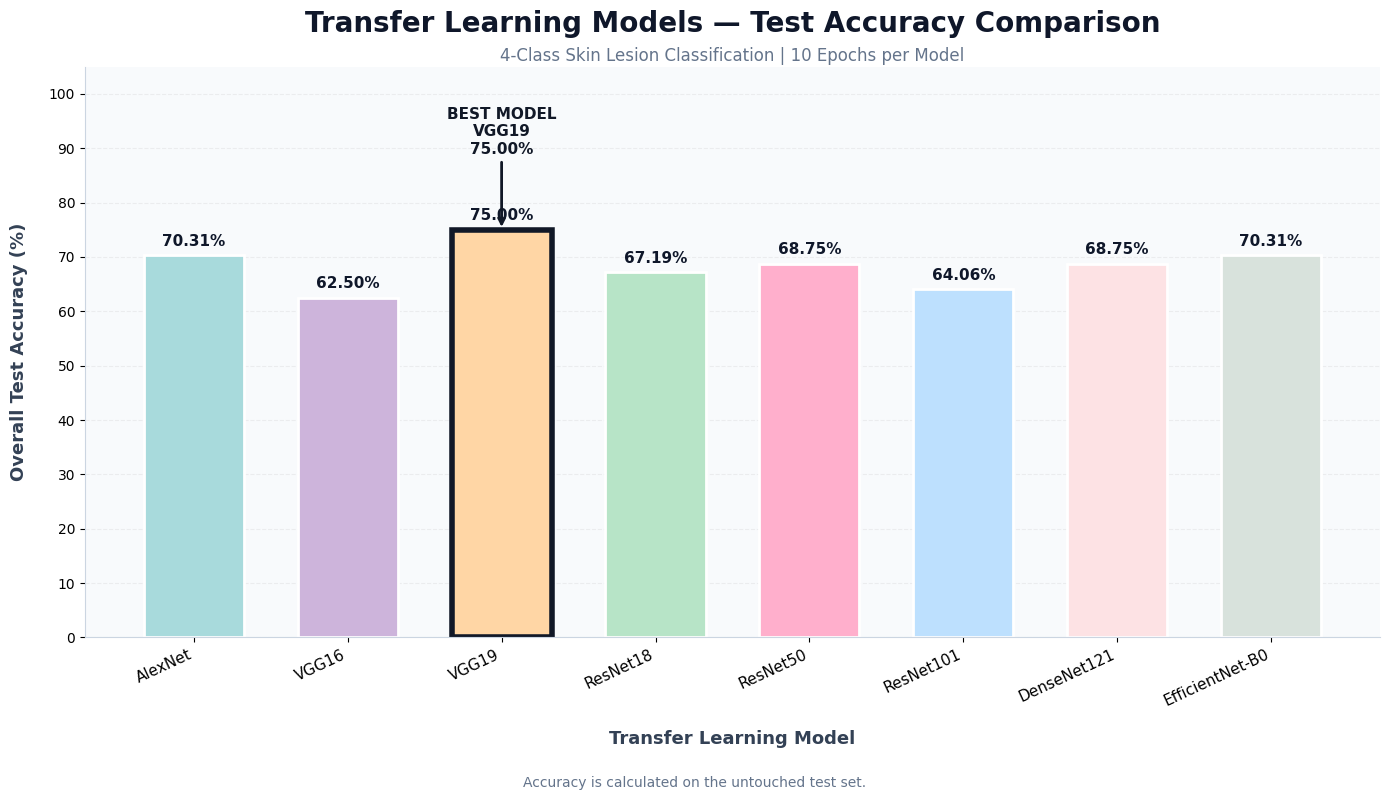

In [41]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD TABLE 1 IF NOT ALREADY AVAILABLE
# ============================================================

if "table1_df" not in globals():

    table1_df = pd.read_csv(
        os.path.join(
            OUTPUT_DIR,
            "Table1_Final.csv"
        )
    )


# ============================================================
# DATA
# ============================================================

model_names = table1_df["Model"]

accuracy_values = table1_df[
    "Accuracy (%)"
].astype(float)


# ============================================================
# ATTRACTIVE COLORS
# ============================================================

colors = [
  "#A8DADC",  # Soft teal
    "#CDB4DB",  # Lavender
    "#FFD6A5",  # Peach
    "#B7E4C7",  # Mint green
    "#FFAFCC",  # Soft pink
    "#BDE0FE",  # Baby blue
    "#FDE2E4",  # Blush
    "#D8E2DC"   # Soft sage
]



# ============================================================
# BEST MODEL
# ============================================================

best_index = accuracy_values.idxmax()

best_model = table1_df.loc[
    best_index,
    "Model"
]

best_accuracy = table1_df.loc[
    best_index,
    "Accuracy (%)"
]


# ============================================================
# CREATE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 8)
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    "#F8FAFC"
)


bars = ax.bar(
    model_names,
    accuracy_values,
    color=colors,
    width=0.65,
    edgecolor="white",
    linewidth=2
)


# ============================================================
# SHOW EXACT ACCURACY ABOVE EVERY BAR
# ============================================================

for bar, value in zip(
    bars,
    accuracy_values
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 1.2,

        f"{value:.2f}%",

        ha="center",
        va="bottom",

        fontsize=11,
        fontweight="bold",

        color="#0F172A"
    )


# ============================================================
# HIGHLIGHT BEST MODEL
# ============================================================

best_position = list(
    model_names
).index(
    best_model
)

best_bar = bars[
    best_position
]

best_bar.set_edgecolor(
    "#111827"
)

best_bar.set_linewidth(
    4
)


ax.annotate(
    f"BEST MODEL\n{best_model}\n{best_accuracy:.2f}%",

    xy=(
        best_bar.get_x()
        + best_bar.get_width() / 2,

        best_accuracy
    ),

    xytext=(
        best_position,
        min(102, best_accuracy + 14)
    ),

    ha="center",

    fontsize=11,
    fontweight="bold",

    color="#111827",

    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        color="#111827"
    )
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Transfer Learning Models — Test Accuracy Comparison",
    fontsize=20,
    fontweight="bold",
    color="#0F172A",
    pad=25
)


ax.text(
    0.5,
    1.01,

    "4-Class Skin Lesion Classification | 10 Epochs per Model",

    transform=ax.transAxes,

    ha="center",

    fontsize=12,
    color="#64748B"
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Transfer Learning Model",
    fontsize=13,
    fontweight="bold",
    color="#334155",
    labelpad=15
)


ax.set_ylabel(
    "Overall Test Accuracy (%)",
    fontsize=13,
    fontweight="bold",
    color="#334155",
    labelpad=15
)


ax.set_ylim(
    0,
    105
)


ax.set_yticks(
    np.arange(
        0,
        101,
        10
    )
)


plt.xticks(
    rotation=25,
    ha="right",
    fontsize=11
)


# ============================================================
# GRID + CLEAN DESIGN
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(
    True
)


ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_color(
    "#CBD5E1"
)

ax.spines["bottom"].set_color(
    "#CBD5E1"
)


# ============================================================
# FOOTNOTE
# ============================================================

plt.figtext(
    0.5,
    0.01,

    "Accuracy is calculated on the untouched test set.",

    ha="center",

    fontsize=10,
    color="#64748B"
)


plt.tight_layout(
    rect=[
        0,
        0.04,
        1,
        1
    ]
)

plt.show()

# Table 2 Accuracy Graph

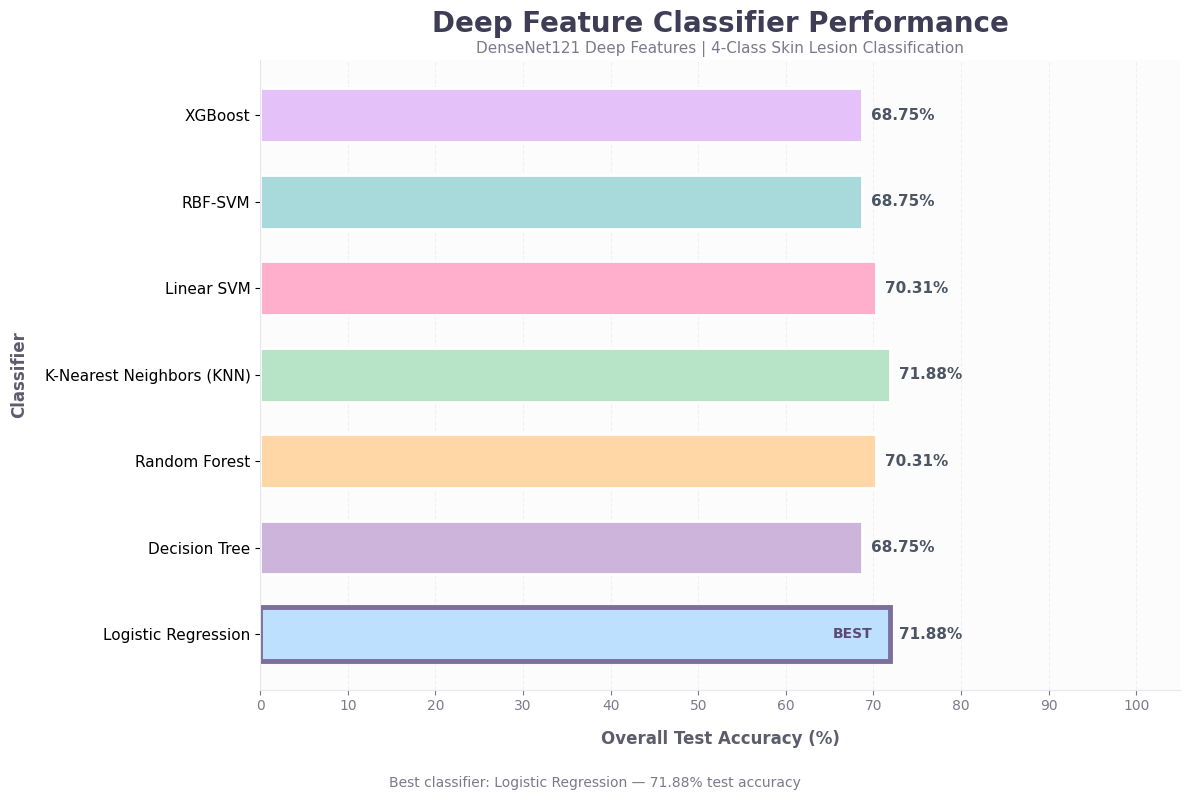

In [45]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



if "table2_df" not in globals():

    table2_df = pd.read_csv(
        os.path.join(
            OUTPUT_DIR,
            "Table2_Final.csv"
        )
    )


classifier_names = table2_df[
    "Classifier"
]

accuracy_values = table2_df[
    "Accuracy (%)"
].astype(float)


colors = [
    "#BDE0FE",   # Baby blue
    "#CDB4DB",   # Lavender
    "#FFD6A5",   # Soft peach
    "#B7E4C7",   # Mint
    "#FFAFCC",   # Soft pink
    "#A8DADC",   # Soft teal
    "#E4C1F9"    # Light violet
]




best_index = accuracy_values.idxmax()

best_classifier = table2_df.loc[
    best_index,
    "Classifier"
]

best_accuracy = float(
    table2_df.loc[
        best_index,
        "Accuracy (%)"
    ]
)


# ============================================================
# CREATE HORIZONTAL BAR GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 8)
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    "#FCFCFD"
)


bars = ax.barh(
    classifier_names,
    accuracy_values,
    color=colors,
    height=0.62,
    edgecolor="white",
    linewidth=2
)



for bar, value in zip(
    bars,
    accuracy_values
):

    ax.text(
        value + 1,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f}%",

        va="center",
        ha="left",

        fontsize=11,
        fontweight="bold",

        color="#4B5563"
    )





best_position = list(
    classifier_names
).index(
    best_classifier
)

best_bar = bars[
    best_position
]

best_bar.set_edgecolor(
    "#7C6F9B"
)

best_bar.set_linewidth(
    3.5
)


ax.text(
    best_accuracy - 2,
    best_bar.get_y()
    + best_bar.get_height() / 2,

    "BEST",

    va="center",
    ha="right",

    fontsize=10,
    fontweight="bold",

    color="#5B4B73"
)



ax.set_title(
    "Deep Feature Classifier Performance",
    fontsize=20,
    fontweight="bold",
    color="#3F3D56",
    pad=20
)


ax.text(
    0.5,
    1.01,

    "DenseNet121 Deep Features | 4-Class Skin Lesion Classification",

    transform=ax.transAxes,

    ha="center",

    fontsize=11,
    color="#7A7A8C"
)



ax.set_xlabel(
    "Overall Test Accuracy (%)",
    fontsize=12,
    fontweight="bold",
    color="#5C5C6D",
    labelpad=12
)

ax.set_ylabel(
    "Classifier",
    fontsize=12,
    fontweight="bold",
    color="#5C5C6D",
    labelpad=12
)


ax.set_xlim(
    0,
    105
)


ax.set_xticks(
    np.arange(
        0,
        101,
        10
    )
)


# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.15
)

ax.set_axisbelow(
    True
)



ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_color(
    "#E5E7EB"
)

ax.spines["bottom"].set_color(
    "#E5E7EB"
)


ax.tick_params(
    axis="y",
    labelsize=11
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#7A7A8C"
)


# ============================================================
# FOOTNOTE
# ============================================================

plt.figtext(
    0.5,
    0.01,

    f"Best classifier: {best_classifier} — {best_accuracy:.2f}% test accuracy",

    ha="center",

    fontsize=10,
    color="#7A7A8C"
)


plt.tight_layout(
    rect=[
        0,
        0.04,
        1,
        1
    ]
)

plt.show()

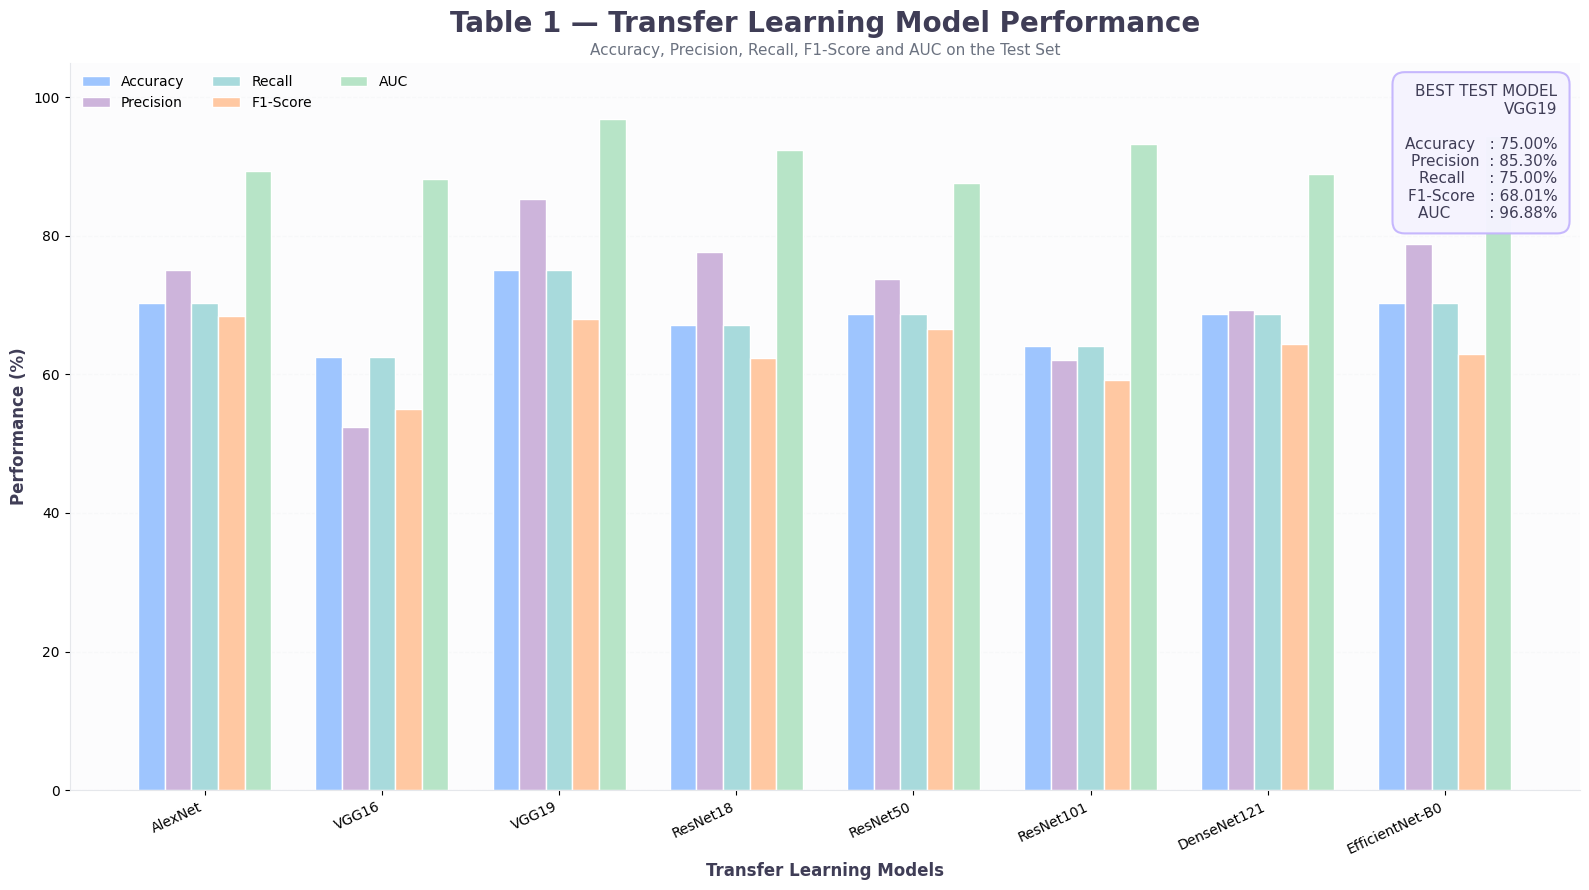


TABLE 1 — EXACT RESULTS



,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,AlexNet,70.31,75.03,70.31,68.47,89.32
1,VGG16,62.50,52.39,62.50,54.99,88.22
2,VGG19,75.00,85.30,75.00,68.01,96.88
3,ResNet18,67.19,77.65,67.19,62.31,92.38
4,ResNet50,68.75,73.76,68.75,66.48,87.63
5,ResNet101,64.06,62.08,64.06,59.18,93.20
6,DenseNet121,68.75,69.34,68.75,64.42,88.93
7,EfficientNet-B0,70.31,78.75,70.31,62.90,94.37


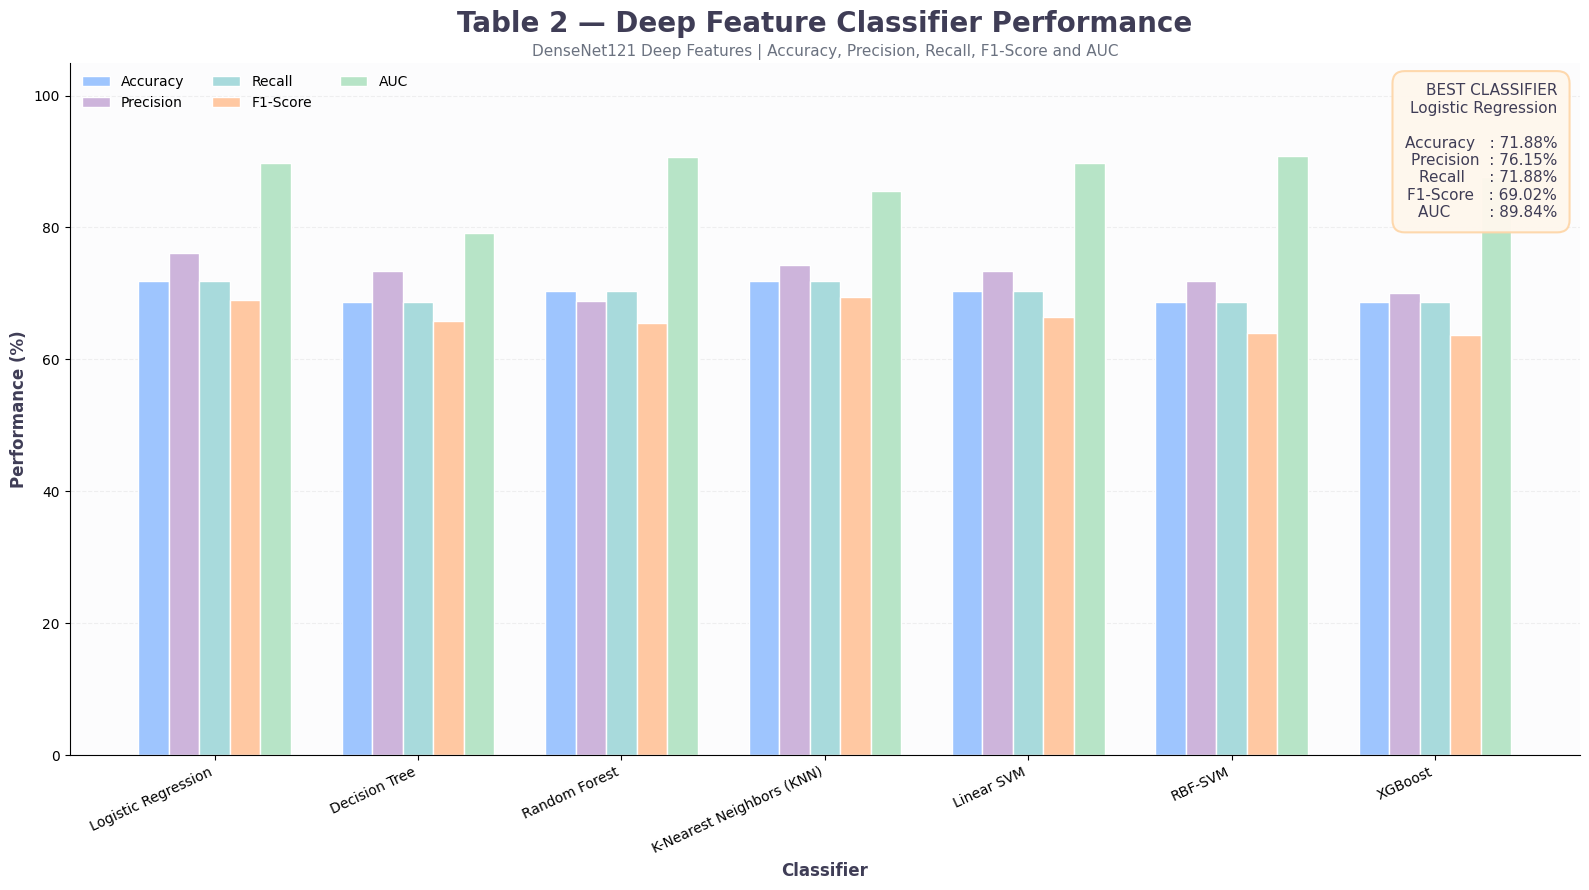


TABLE 2 — EXACT RESULTS



,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,Deep Features,Logistic Regression,71.88,76.15,71.88,69.02,89.84
1,Deep Features,Decision Tree,68.75,73.33,68.75,65.88,79.17
2,Deep Features,Random Forest,70.31,68.89,70.31,65.47,90.61
3,Deep Features,K-Nearest Neighbors (KNN),71.88,74.36,71.88,69.41,85.53
4,Deep Features,Linear SVM,70.31,73.47,70.31,66.36,89.84
5,Deep Features,RBF-SVM,68.75,71.86,68.75,63.99,90.85
6,Deep Features,XGBoost,68.75,70.08,68.75,63.69,87.60


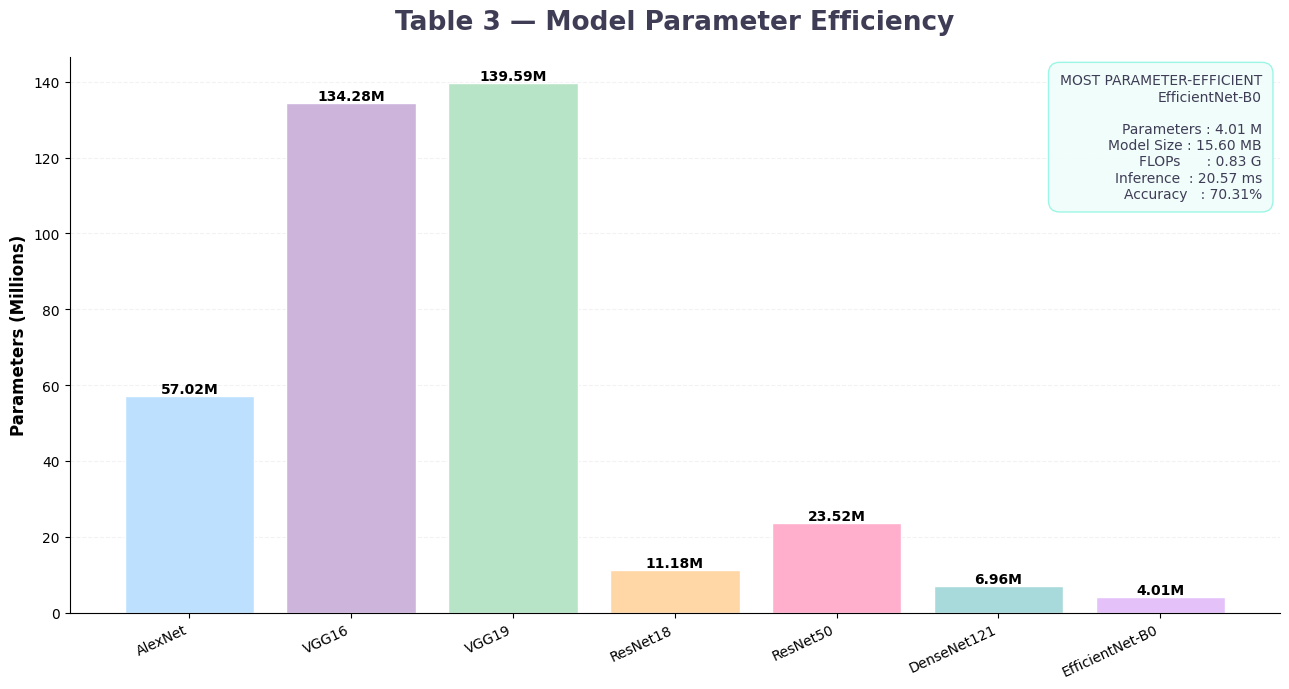

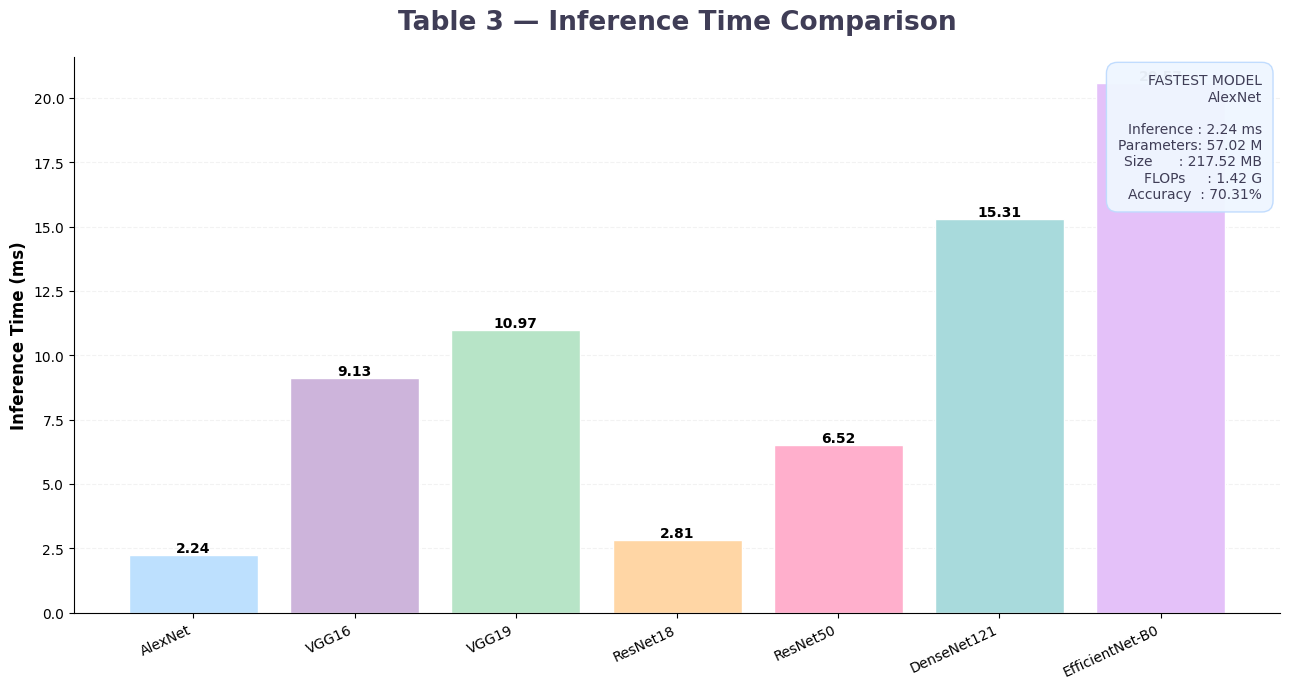


TABLE 3 — EXACT RESULTS



,Model,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
0,AlexNet,57.02,217.52,1.42,2.24,70.31
1,VGG16,134.28,512.24,30.93,9.13,62.50
2,VGG19,139.59,532.49,39.26,10.97,75.00
3,ResNet18,11.18,42.72,3.65,2.81,67.19
4,ResNet50,23.52,90.01,8.26,6.52,68.75
5,DenseNet121,6.96,27.13,5.79,15.31,68.75
6,EfficientNet-B0,4.01,15.60,0.83,20.57,70.31


In [44]:
# ============================================================
# FINAL PROFESSIONAL VISUALIZATIONS
# TABLE 1 + TABLE 2 + TABLE 3
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD ALL FINAL TABLES
# ============================================================

table1_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table1_Final.csv"
    )
)

table2_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table2_Final.csv"
    )
)

table3_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table3_Final.csv"
    )
)


# ============================================================
# SOFT PROFESSIONAL COLOR PALETTE
# ============================================================

ACC_COLOR = "#9EC5FE"      # soft blue
PREC_COLOR = "#CDB4DB"     # lavender
RECALL_COLOR = "#A8DADC"   # soft teal
F1_COLOR = "#FFC8A2"       # peach
AUC_COLOR = "#B7E4C7"      # mint

TEXT_COLOR = "#3F3D56"
SECONDARY_TEXT = "#6B7280"
BACKGROUND = "#FCFCFD"
GRID_COLOR = "#E5E7EB"


# ============================================================
# TABLE 1
# TRANSFER LEARNING MODELS
# ============================================================

models = table1_df["Model"].tolist()

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)",
    "AUC (%)"
]

metric_colors = [
    ACC_COLOR,
    PREC_COLOR,
    RECALL_COLOR,
    F1_COLOR,
    AUC_COLOR
]


x = np.arange(
    len(models)
)

width = 0.15


fig, ax = plt.subplots(
    figsize=(16, 9)
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    BACKGROUND
)


# ------------------------------------------------------------
# GROUPED BARS
# ------------------------------------------------------------

for i, metric in enumerate(metrics):

    offset = (
        i - 2
    ) * width

    bars = ax.bar(
        x + offset,
        table1_df[metric],
        width,
        label=metric.replace(" (%)", ""),
        color=metric_colors[i],
        edgecolor="white",
        linewidth=1
    )


# ------------------------------------------------------------
# BEST MODEL BASED ON TEST ACCURACY
# ------------------------------------------------------------

best_idx = table1_df[
    "Accuracy (%)"
].idxmax()

best_row = table1_df.loc[
    best_idx
]

best_model = best_row[
    "Model"
]


# ------------------------------------------------------------
# CORNER RESULT CARD
# ------------------------------------------------------------

result_text = (
    f"BEST TEST MODEL\n"
    f"{best_model}\n\n"
    f"Accuracy   : {best_row['Accuracy (%)']:.2f}%\n"
    f"Precision  : {best_row['Precision (%)']:.2f}%\n"
    f"Recall     : {best_row['Recall (%)']:.2f}%\n"
    f"F1-Score   : {best_row['F1-Score (%)']:.2f}%\n"
    f"AUC        : {best_row['AUC (%)']:.2f}%"
)


ax.text(
    0.985,
    0.97,
    result_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    horizontalalignment="right",
    color=TEXT_COLOR,
    fontweight="medium",

    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#F5F3FF",
        edgecolor="#C4B5FD",
        linewidth=1.5,
        alpha=0.96
    )
)


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ax.set_title(
    "Table 1 — Transfer Learning Model Performance",
    fontsize=20,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Accuracy, Precision, Recall, F1-Score and AUC on the Test Set",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color=SECONDARY_TEXT
)


ax.set_ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR
)

ax.set_xlabel(
    "Transfer Learning Models",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    models,
    rotation=25,
    ha="right",
    fontsize=10
)

ax.set_ylim(
    0,
    105
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18,
    color=GRID_COLOR
)

ax.set_axisbelow(
    True
)


ax.legend(
    loc="upper left",
    ncol=3,
    frameon=False,
    fontsize=10
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_color(GRID_COLOR)

ax.spines[
    "bottom"
].set_color(GRID_COLOR)


plt.tight_layout()

plt.show()



# ============================================================
# TABLE 1 — DISPLAY EXACT VALUES TOO
# ============================================================

print("\nTABLE 1 — EXACT RESULTS\n")

display(
    table1_df.style.format({

        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}",
        "AUC (%)": "{:.2f}"

    })
)



# ============================================================
# TABLE 2
# DEEP FEATURE CLASSIFIERS
# ============================================================

classifiers_names = table2_df[
    "Classifier"
].tolist()

x = np.arange(
    len(classifiers_names)
)


fig, ax = plt.subplots(
    figsize=(16, 9)
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    BACKGROUND
)


# ------------------------------------------------------------
# GROUPED BARS
# ------------------------------------------------------------

for i, metric in enumerate(metrics):

    offset = (
        i - 2
    ) * width

    ax.bar(
        x + offset,
        table2_df[metric],
        width,
        label=metric.replace(" (%)", ""),
        color=metric_colors[i],
        edgecolor="white",
        linewidth=1
    )


# ------------------------------------------------------------
# BEST CLASSIFIER
# ------------------------------------------------------------

best_classifier_idx = table2_df[
    "Accuracy (%)"
].idxmax()

best_classifier_row = table2_df.loc[
    best_classifier_idx
]

best_classifier = best_classifier_row[
    "Classifier"
]


# ------------------------------------------------------------
# CORNER RESULT CARD
# ------------------------------------------------------------

classifier_text = (
    f"BEST CLASSIFIER\n"
    f"{best_classifier}\n\n"
    f"Accuracy   : {best_classifier_row['Accuracy (%)']:.2f}%\n"
    f"Precision  : {best_classifier_row['Precision (%)']:.2f}%\n"
    f"Recall     : {best_classifier_row['Recall (%)']:.2f}%\n"
    f"F1-Score   : {best_classifier_row['F1-Score (%)']:.2f}%\n"
    f"AUC        : {best_classifier_row['AUC (%)']:.2f}%"
)


ax.text(
    0.985,
    0.97,
    classifier_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    horizontalalignment="right",
    color=TEXT_COLOR,

    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#FFF7ED",
        edgecolor="#FED7AA",
        linewidth=1.5,
        alpha=0.96
    )
)


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ax.set_title(
    "Table 2 — Deep Feature Classifier Performance",
    fontsize=20,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=22
)


ax.text(
    0.5,
    1.01,
    "DenseNet121 Deep Features | Accuracy, Precision, Recall, F1-Score and AUC",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color=SECONDARY_TEXT
)


ax.set_ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR
)


ax.set_xlabel(
    "Classifier",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    classifiers_names,
    rotation=25,
    ha="right",
    fontsize=10
)


ax.set_ylim(
    0,
    105
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(
    True
)


ax.legend(
    loc="upper left",
    ncol=3,
    frameon=False,
    fontsize=10
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


plt.tight_layout()

plt.show()



# ============================================================
# TABLE 2 — EXACT RESULTS
# ============================================================

print("\nTABLE 2 — EXACT RESULTS\n")

display(
    table2_df.style.format({

        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}",
        "AUC (%)": "{:.2f}"

    })
)



# ============================================================
# TABLE 3
# COMPUTATIONAL EFFICIENCY
# ============================================================

models3 = table3_df[
    "Model"
].tolist()


efficiency_colors = [
    "#BDE0FE",
    "#CDB4DB",
    "#B7E4C7",
    "#FFD6A5",
    "#FFAFCC",
    "#A8DADC",
    "#E4C1F9"
]


# ============================================================
# TABLE 3 — PARAMETERS GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 7)
)

bars = ax.bar(
    models3,
    table3_df["Parameters (M)"],
    color=efficiency_colors,
    edgecolor="white"
)


for bar, value in zip(
    bars,
    table3_df["Parameters (M)"]
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


smallest_param_idx = table3_df[
    "Parameters (M)"
].idxmin()

smallest_param_row = table3_df.loc[
    smallest_param_idx
]


summary = (
    f"MOST PARAMETER-EFFICIENT\n"
    f"{smallest_param_row['Model']}\n\n"
    f"Parameters : {smallest_param_row['Parameters (M)']:.2f} M\n"
    f"Model Size : {smallest_param_row['Model Size (MB)']:.2f} MB\n"
    f"FLOPs      : {smallest_param_row['FLOPs (G)']:.2f} G\n"
    f"Inference  : {smallest_param_row['Inference Time (ms)']:.2f} ms\n"
    f"Accuracy   : {smallest_param_row['Accuracy (%)']:.2f}%"
)


ax.text(
    0.985,
    0.97,
    summary,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color=TEXT_COLOR,

    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#F0FDFA",
        edgecolor="#99F6E4",
        alpha=0.96
    )
)


ax.set_title(
    "Table 3 — Model Parameter Efficiency",
    fontsize=19,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=20
)

ax.set_ylabel(
    "Parameters (Millions)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.16
)

ax.set_axisbelow(
    True
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()



# ============================================================
# TABLE 3 — INFERENCE TIME GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 7)
)


bars = ax.bar(
    models3,
    table3_df["Inference Time (ms)"],
    color=efficiency_colors,
    edgecolor="white"
)


for bar, value in zip(
    bars,
    table3_df["Inference Time (ms)"]
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


fastest_idx = table3_df[
    "Inference Time (ms)"
].idxmin()

fastest_row = table3_df.loc[
    fastest_idx
]


fast_text = (
    f"FASTEST MODEL\n"
    f"{fastest_row['Model']}\n\n"
    f"Inference : {fastest_row['Inference Time (ms)']:.2f} ms\n"
    f"Parameters: {fastest_row['Parameters (M)']:.2f} M\n"
    f"Size      : {fastest_row['Model Size (MB)']:.2f} MB\n"
    f"FLOPs     : {fastest_row['FLOPs (G)']:.2f} G\n"
    f"Accuracy  : {fastest_row['Accuracy (%)']:.2f}%"
)


ax.text(
    0.985,
    0.97,
    fast_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color=TEXT_COLOR,

    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#EFF6FF",
        edgecolor="#BFDBFE",
        alpha=0.96
    )
)


ax.set_title(
    "Table 3 — Inference Time Comparison",
    fontsize=19,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=20
)


ax.set_ylabel(
    "Inference Time (ms)",
    fontsize=12,
    fontweight="bold"
)


plt.xticks(
    rotation=25,
    ha="right"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.16
)

ax.set_axisbelow(
    True
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()

plt.show()



# ============================================================
# TABLE 3 — EXACT RESULTS
# ============================================================

print("\nTABLE 3 — EXACT RESULTS\n")

display(
    table3_df.style.format({

        "Parameters (M)": "{:.2f}",
        "Model Size (MB)": "{:.2f}",
        "FLOPs (G)": "{:.2f}",
        "Inference Time (ms)": "{:.2f}",
        "Accuracy (%)": "{:.2f}"

    })
)

# table 3

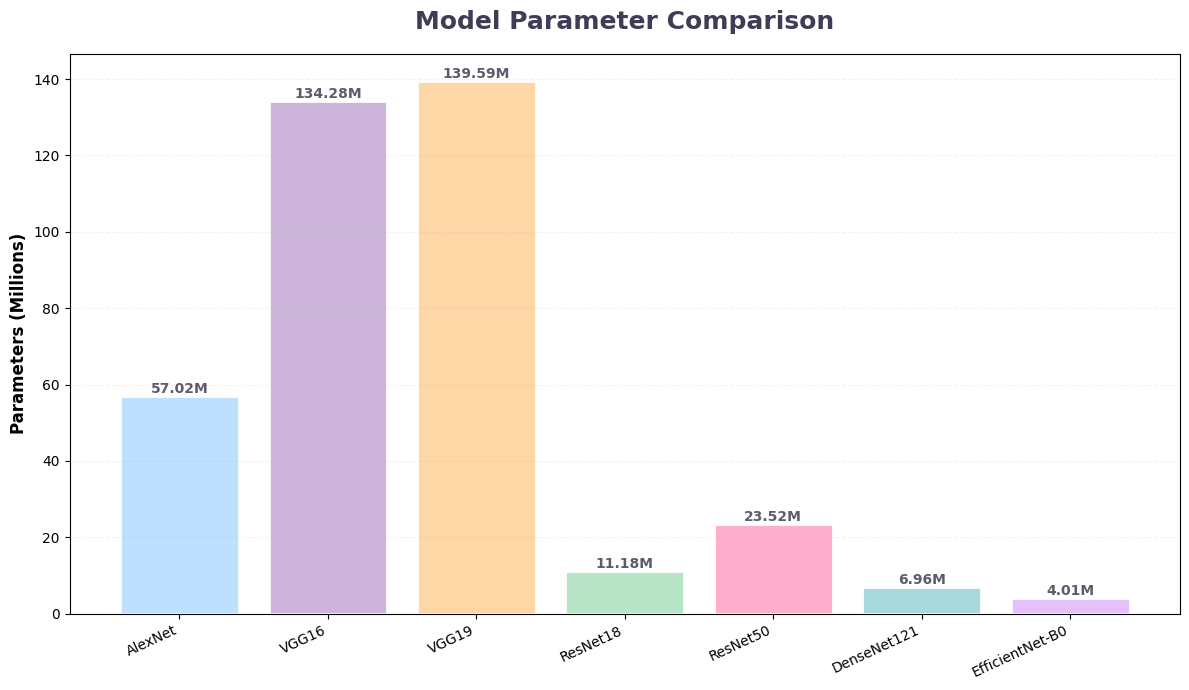

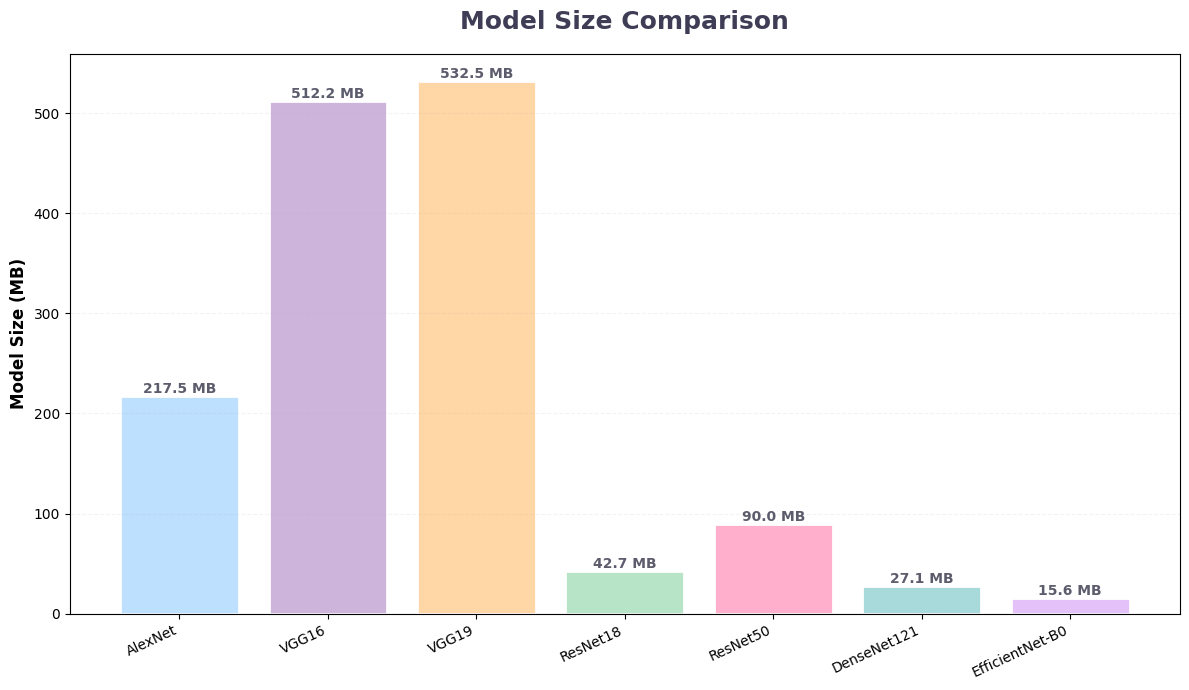

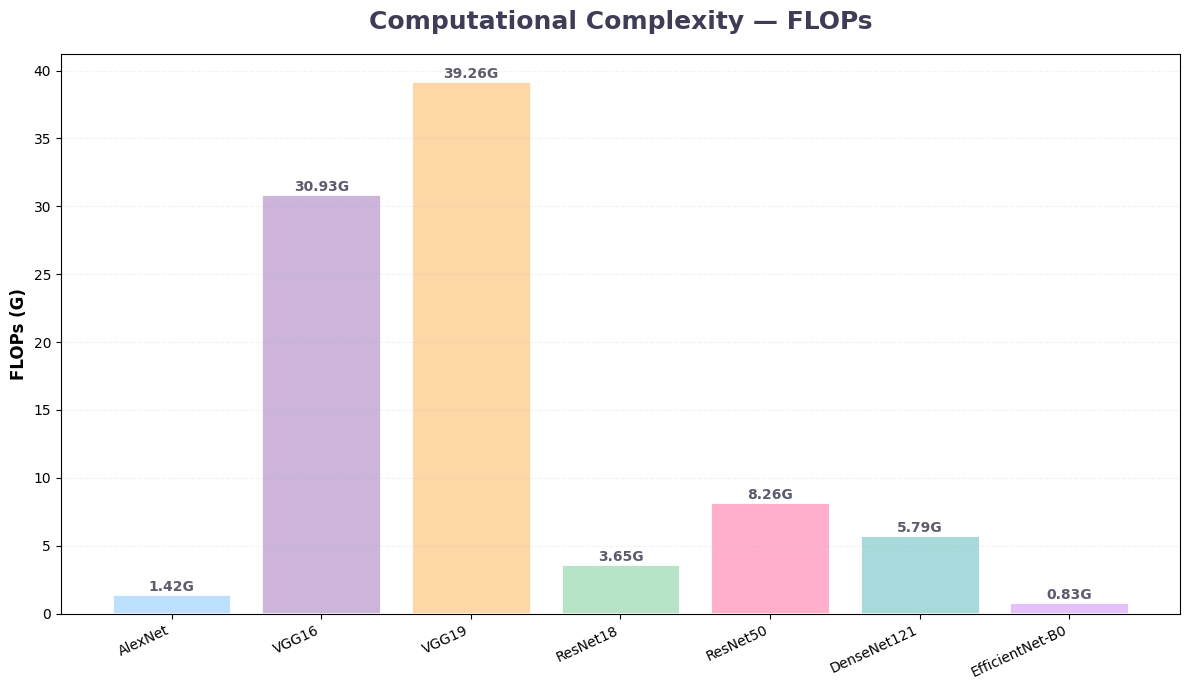

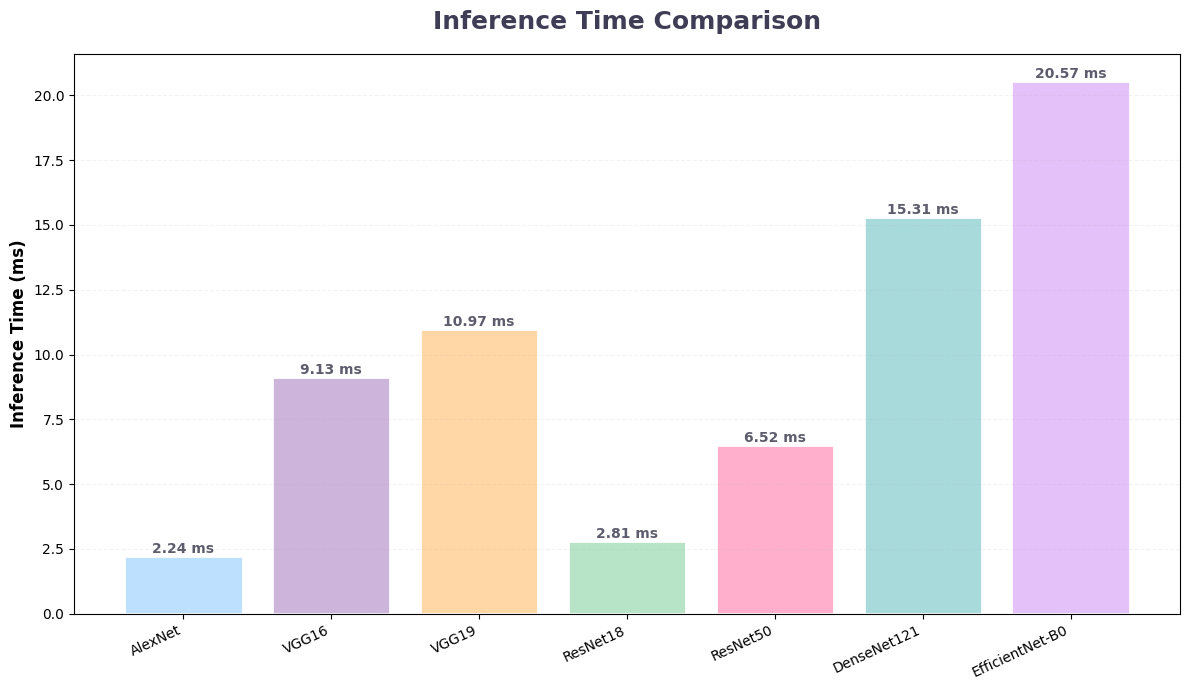

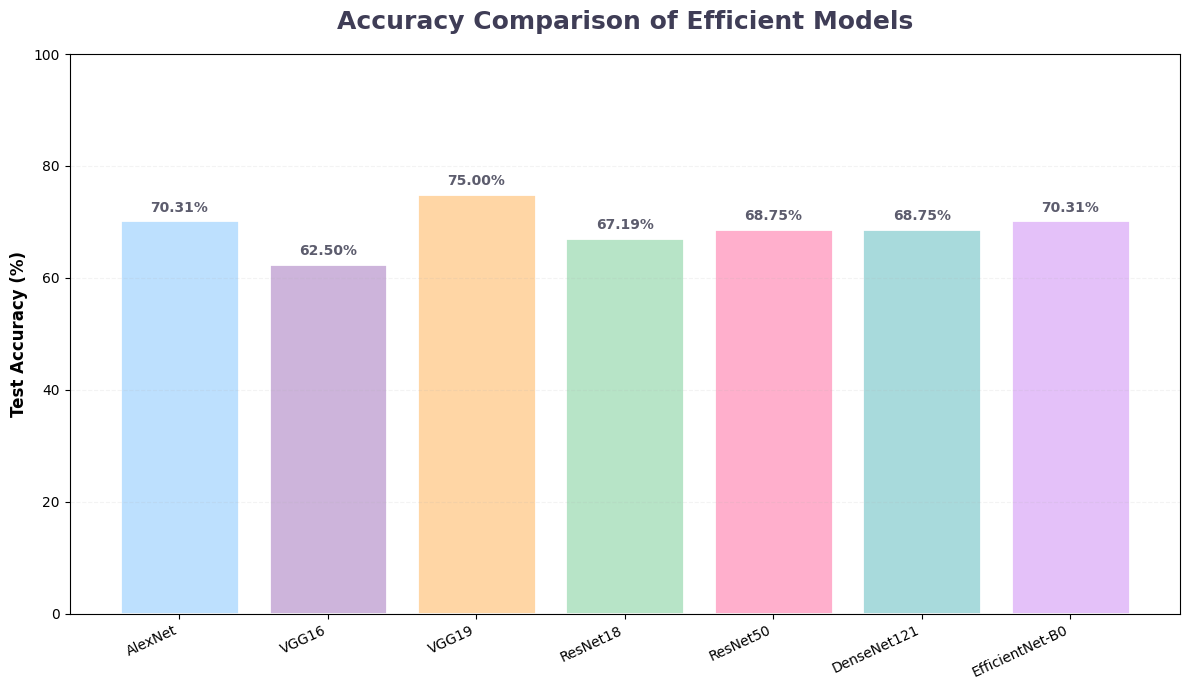

In [43]:

import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD TABLE 3 IF NEEDED
# ============================================================

if "table3_df" not in globals():

    table3_df = pd.read_csv(
        os.path.join(
            OUTPUT_DIR,
            "Table3_Final.csv"
        )
    )


# ============================================================
# SOFT COLOR PALETTE
# ============================================================

soft_colors = [
    "#BDE0FE",   # baby blue
    "#CDB4DB",   # lavender
    "#FFD6A5",   # peach
    "#B7E4C7",   # mint
    "#FFAFCC",   # soft pink
    "#A8DADC",   # teal
    "#E4C1F9"    # violet
]


model_names = table3_df["Model"]


# ============================================================
# 1. PARAMETERS
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_names,
    table3_df["Parameters (M)"],
    color=soft_colors,
    edgecolor="white",
    linewidth=2
)

plt.title(
    "Model Parameter Comparison",
    fontsize=18,
    fontweight="bold",
    color="#3F3D56",
    pad=18
)

plt.ylabel(
    "Parameters (Millions)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

for bar, value in zip(
    bars,
    table3_df["Parameters (M)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#5C5C6D"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 2. MODEL SIZE
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_names,
    table3_df["Model Size (MB)"],
    color=soft_colors,
    edgecolor="white",
    linewidth=2
)

plt.title(
    "Model Size Comparison",
    fontsize=18,
    fontweight="bold",
    color="#3F3D56",
    pad=18
)

plt.ylabel(
    "Model Size (MB)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

for bar, value in zip(
    bars,
    table3_df["Model Size (MB)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f} MB",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#5C5C6D"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 3. FLOPs
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_names,
    table3_df["FLOPs (G)"],
    color=soft_colors,
    edgecolor="white",
    linewidth=2
)

plt.title(
    "Computational Complexity — FLOPs",
    fontsize=18,
    fontweight="bold",
    color="#3F3D56",
    pad=18
)

plt.ylabel(
    "FLOPs (G)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

for bar, value in zip(
    bars,
    table3_df["FLOPs (G)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}G",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#5C5C6D"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 4. INFERENCE TIME
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_names,
    table3_df["Inference Time (ms)"],
    color=soft_colors,
    edgecolor="white",
    linewidth=2
)

plt.title(
    "Inference Time Comparison",
    fontsize=18,
    fontweight="bold",
    color="#3F3D56",
    pad=18
)

plt.ylabel(
    "Inference Time (ms)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

for bar, value in zip(
    bars,
    table3_df["Inference Time (ms)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f} ms",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#5C5C6D"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 5. ACCURACY
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    model_names,
    table3_df["Accuracy (%)"],
    color=soft_colors,
    edgecolor="white",
    linewidth=2
)

plt.title(
    "Accuracy Comparison of Efficient Models",
    fontsize=18,
    fontweight="bold",
    color="#3F3D56",
    pad=18
)

plt.ylabel(
    "Test Accuracy (%)",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

for bar, value in zip(
    bars,
    table3_df["Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#5C5C6D"
    )

plt.tight_layout()
plt.show()